# Seq2Seq LSTM avec PyTorch

Ce notebook implémente un modèle **Sequence-to-Sequence (Seq2Seq)** basé sur des réseaux LSTM pour résoudre une tâche de traduction/transformation de séquences. Le modèle utilise l'architecture encodeur-décodeur classique pour apprendre à mapper des séquences d'entrée vers des séquences de sortie.

## Architecture générale
- **Encodeur** : Traite la séquence d'entrée et encode l'information dans un état latent
- **Décodeur** : Génère la séquence de sortie token par token à partir de l'état encodé
- **Teacher Forcing** : Technique d'entraînement qui utilise les vraies valeurs cibles pendant l'entraînement

## Importation des bibliothèques et configuration du dispositif

Cette section importe toutes les bibliothèques nécessaires :
- **PyTorch** : Framework de deep learning principal
- **torch.nn** : Modules de réseaux de neurones
- **torch.optim** : Optimiseurs pour l'entraînement
- **DataLoader** : Gestion efficace des batches de données
- **pad_sequence** : Fonction pour uniformiser la longueur des séquences

Le code détecte automatiquement si un GPU est disponible et affiche les informations de mémoire correspondantes.

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import KFold
import random
import math
import time
from random import choice
from IPython.display import clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if str(device) == "cuda":
    print("GPU detected.")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Free: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")
else:
    print("No GPU detected. Using CPU.")


No GPU detected. Using CPU.


## Préparation des données
Les données d'apprentissage sont chargées à partir du fichier `long-comp_forlearning.txt`, l'évaluation du modèle est calculé à partir du fichier `long-comp_fortesting.txt`. Voir le notebook `1-MAP_IA_BuildDataSet.ipynb` pour la génération de ces fichiers.

### Structure des données
Le fichier contient des paires de séquences séparées par des tabulations :
- **Séquence source** : La séquence d'entrée à transformer
- **Séquence cible** : La transformation attendue

Par exemple : `AAAAAAAA` → `[A]` (compression d'une séquence répétée)

### Fonction de normalisation des séquences

Cette fonction standardise le format des séquences :
1. **Supprime tous les espaces** de la chaîne d'entrée
2. **Ajoute un espace entre chaque caractère** pour créer une tokenisation au niveau caractère

Cette normalisation est cruciale pour assurer une tokenisation cohérente des données d'entrée et de sortie.

In [2]:
def normalizeSequence(s):
    s = s.replace(" ", ""); # suppression de tous les espaces
    return " ".join(s) # ajout d'un seul espace entre chaque caractère

### Chargement et préparation des données

Cette section effectue plusieurs opérations importantes :

1. **Lecture du fichier** : Charge les paires de séquences depuis le fichier d'entraînement
2. **Normalisation** : Applique la fonction de normalisation à chaque séquence
3. **Séparation** : Divise les paires en listes SRC (source) et TRG (target)
4. **Calcul de longueur maximale** : Détermine la longueur de la séquence la plus longue
5. **Tokenisation** : Sépare chaque séquence en tokens individuels
6. **Ajout de tokens spéciaux** :
   - `<sos>` : Start of Sequence (début de séquence)
   - `<eos>` : End of Sequence (fin de séquence)
   - `<pad>` : Padding (remplissage pour uniformiser les longueurs)

### Construction des vocabulaires
- **Vocabulaire source (SRC_VOCAB)** : Mapping token → index pour les séquences d'entrée
- **Vocabulaire cible (TRG_VOCAB)** : Mapping token → index pour les séquences de sortie
- **Vocabulaires inverses (itos)** : Mapping index → token pour la conversion inverse

In [ ]:
print("Reading lines...")

# Read the file and split into lines
lines = open('long-comp_forlearning.txt', encoding='utf-8').\
    read().strip().split('\n')

# Split every line into pairs and normalize
pairs = [[normalizeSequence(s) for s in l.split('\t')] for l in lines]

# Exemple de ce que l'on veut obtenir dans SRC et TRG :
# SRC = ["AAAAAAAA", "ECECECECEC", ...]
# TRG = ["[A]", "[EC]", ...]
SRC = []
TRG = []
MAX_LENGTH = -1
print("Read %s sentence pairs" % len(pairs))
for pair in pairs:
    SRC.append(pair[0])
    TRG.append(pair[1])
    if len(pair[0]) > MAX_LENGTH:
        MAX_LENGTH = len(pair[0])
    if len(pair[1]) > MAX_LENGTH:
        MAX_LENGTH = len(pair[1])
print("One Example: "+str(choice(pairs)))

# Tokenisation
SRC = [s.split() for s in SRC]
TRG = [t.split() for t in TRG]
# Ajout tokens spéciaux
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
PAD_TOKEN = "<pad>"
TRG = [[SOS_TOKEN] + t + [EOS_TOKEN] for t in TRG]

# Construction vocabulaire
def build_vocab(sentences):
    vocab = {PAD_TOKEN:0, SOS_TOKEN:1, EOS_TOKEN:2}
    idx = 3
    for s in sentences:
        for tok in s:
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

SRC_VOCAB = build_vocab(SRC)
TRG_VOCAB = build_vocab(TRG)

print("Counted tokens:")
print("SRC: ", len(SRC_VOCAB))
print("TRG: ", len(TRG_VOCAB))
print("Max token count: "+str(int((MAX_LENGTH+1)/2))) # on ne compte pas les espaces

# Construction des dictionnaires inversés
SRC_itos = {i:s for s,i in SRC_VOCAB.items()}
TRG_itos = {i:s for s,i in TRG_VOCAB.items()}

# Récupération de l'index du PAD
PAD_IDX = SRC_VOCAB[PAD_TOKEN]

# Taille du vocabulaire pour les séquences en entrée (nombre total de token uniques dans le corpus).
INPUT_DIM = len(SRC_VOCAB)
# Taille du vocabulaire pour les séquences en sortie (nombre total de token uniques dans le corpus).
OUTPUT_DIM = len(TRG_VOCAB)

Reading lines...
Read 48000 sentence pairs
One Example: ['L A A A A A A A A L A A L A A A A A A A A A A A A L A A A A A A A A A', '[ L [ A ] ]']
Counted tokens:
SRC:  29
TRG:  32
Max token count: 52


### Dataset + DataLoader

Cette section implémente la gestion efficace des données pour l'entraînement :

#### Classe TranslationDataset
- Hérite de `torch.utils.data.Dataset`
- **Encode les séquences** : Convertit les tokens en indices numériques
- **Stockage optimisé** : Garde les données encodées en mémoire
- **Interface standard** : Implémente `__len__` et `__getitem__` pour PyTorch

#### Fonction collate_fn
- **Padding automatique** : Uniformise la longueur des séquences dans un batch
- **Gestion des batches** : Organise les données pour un traitement parallèle efficace
- **batch_first=True** : Format compatible avec les modèles LSTM

In [4]:
# Convertit les tokens de "sentence" en tenseur PyTorch (tableau PyTorch)
def encode(sentence, vocab):
    return torch.tensor([vocab[tok] for tok in sentence])

# Encode les dataset src et trg
class TranslationDataset(Dataset):
    def __init__(self, src, trg, src_vocab, trg_vocab):
        self.src = [encode(s, src_vocab) for s in src]
        self.trg = [encode(t, trg_vocab) for t in trg]
    def __len__(self):
        return len(self.src)
    def __getitem__(self, idx):
        return self.src[idx], self.trg[idx]

# Uniformise la longueur des séquences dans un batch pour qu'ils aient tous la même taille
def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    trg_batch = pad_sequence(trg_batch, padding_value=PAD_IDX, batch_first=True)
    return src_batch, trg_batch

## Modèle Seq2Seq

L'architecture Seq2Seq est composée de trois composants principaux :

### 1. Encodeur (Encoder)
**Rôle** : Traite la séquence d'entrée et encode l'information dans un état latent

**Composants** :
- **Embedding Layer** : Convertit les indices de tokens en vecteurs denses de dimension `emb_dim`
- **LSTM Multi-couches** : Traite séquentiellement les embeddings
  - `batch_first=True` : Format (batch_size, seq_len, features)
  - `dropout` : Régularisation pour éviter le surapprentissage
- **États cachés** : Retourne les états finaux (hidden, cell) qui encodent toute l'information de la séquence

In [5]:
class Encoder(nn.Module):
    # input_dim: Taille du vocabulaire (nombre total de tokens uniques dans le corpus).
    # emb_dim: Dimension des vecteurs d'embedding (taille du vecteur dense pour chaque token).
    # hid_dim : Dimension de l'état caché (hidden size) du LSTM.
    # n_layers: Nombre de couches LSTM empilées.
    # dropout: Taux de dropout entre les couches LSTM
    # bidirectional: Définit si on veut un LSTM unidirectionnel ou bidirectionnel
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout, bidirectional):
        super().__init__()
        # Création de l'embedding: transformation des indices de tokens (entiers) en vecteurs denses (représentations vectorielles)
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)
        # Création du réseau LSTM: traite les séquences de vecteurs d'embedding pour capturer des dépendances entre tokens
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout, batch_first=True, bidirectional=bidirectional)
        # Définition du dropout: désactivation aléatoirement d'une fraction des neurones pendant l'entraînement pour éviter le surapprentissage
        self.dropout = nn.Dropout(dropout)
        self.bidirectional = bidirectional
        self.n_layers = n_layers
        self.hid_dim = hid_dim
        # Couche de projection pour réduire la dimension quand bidirectionnel
        if bidirectional:
            self.hidden_projection = nn.Linear(hid_dim * 2, hid_dim)
            self.cell_projection = nn.Linear(hid_dim * 2, hid_dim)
    # src: Tenseur d'indices de tokens (entiers) représentant la séquence source.
    def forward(self, src):
        # Passe le tenseur source à travers la couche d'embedding  pour obtenir des vecteurs denses.
        embedding = self.embedding(src)
        # Applique un dropout aux vecteurs denses pour régulariser le modèle et éviter le surapprentissage.
        embedded = self.dropout(embedding)
        # Passe les vecteurs denses dropped à travers le LSTM pour capturer les dépendances dans la séquence.
        _, (hidden, cell) = self.rnn(embedded)
        # on a récupèré Les états finaux du LSTM (après avoir traité toute la séquence) et on les retourne
        # hidden : État caché final
        # cell : État de la cellule finale (mémoire à long terme du LSTM)
        if self.bidirectional :
            # Pour un LSTM bidirectionnel, on a (n_layers * 2, batch_size, hid_dim)
            # On doit combiner les directions et reformater pour le décodeur
            
            # Séparer les directions forward et backward
            # hidden: (n_layers * 2, batch_size, hid_dim) -> (n_layers, 2, batch_size, hid_dim)
            hidden = hidden.view(self.n_layers, 2, hidden.size(1), self.hid_dim)
            cell = cell.view(self.n_layers, 2, cell.size(1), self.hid_dim)
            
            # Concaténer les directions pour chaque couche
            # (n_layers, batch_size, hid_dim * 2)
            hidden = torch.cat([hidden[:, 0, :, :], hidden[:, 1, :, :]], dim=2)
            cell = torch.cat([cell[:, 0, :, :], cell[:, 1, :, :]], dim=2)
            
            # Projeter vers la dimension attendue par le décodeur
            # (n_layers, batch_size, hid_dim)
            hidden = self.hidden_projection(hidden)
            cell = self.cell_projection(cell)
        
        return hidden, cell

### 2. Décodeur (Decoder) 
**Rôle** : Génère la séquence de sortie token par token

**Composants** :
- **Embedding Layer** : Même principe que l'encodeur
- **LSTM** : Utilise les états de l'encodeur comme initialisation
- **Couche linéaire finale** : Projette l'état caché vers le vocabulaire de sortie
- **Génération autoregressive** : Chaque token généré influence le suivant

In [6]:
class Decoder(nn.Module):
    # output_dim: Taille du vocabulaire (nombre total de tokens uniques dans le corpus).
    # emb_dim: Dimension des vecteurs d'embedding (taille du vecteur dense pour chaque token).
    # hid_dim : Dimension de l'état caché (hidden size) du LSTM.
    # n_layers: Nombre de couches LSTM empilées.
    # dropout: Taux de dropout entre les couches LSTM
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        # transformation des indices de tokens (entiers) en vecteurs denses (représentations vectorielles)
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        # création d'un réseau LSTM, qui traite les séquences de vecteurs d'embedding pour capturer des dépendances entre tokens
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        # désactive aléatoirement une fraction des neurones pendant l'entraînement pour éviter le surapprentissage
        self.dropout = nn.Dropout(dropout)
        # Projection des représentations cachées du LSTM (de dimension hid_dim) vers l'espace du vocabulaire de sortie (de dimension output_dim).
        self.fc_out = nn.Linear(hid_dim, output_dim)
    # cur_tok: Tenseur d'indices de tokens (entiers) représentant le token courant à décoder.
    # hidden: Tenseur représentant l'état caché du LSTM de l'étape précédente.
    # cell: Tenseur représentant l'état de la cellule (mémoire à long terme) du LSTM de l'étape précédente.
    def forward(self, cur_tok, hidden, cell):
        # Ajoute une dimension à cur_tok pour le mettre au format attendu par le LSTM.
        cur_tok = cur_tok.unsqueeze(1)
        # Convertit le tenseur de tokens (cur_tok) en vecteurs denses via la couche d'embedding.
        embedding = self.embedding(cur_tok)
        # Applique un dropout aux vecteurs denses pour régulariser le modèle et éviter le surapprentissage.
        embedded = self.dropout(embedding)
        # Passe les vecteurs denses dropped à travers le LSTM pour mettre à jour les états cachés et générer une sortie pour le mot courant.
        # output -> Sortie du LSTM pour le token courant.
        # (hidden, cell) -> États mis à jour du LSTM pour l'étape suivante.
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        # Suppression de la dimention précédemment ajoutée
        output = output.squeeze(1)
        # Passe le vecteur de sortie du LSTM à travers une couche linéaire pour obtenir les scores/logits pour chaque mot du vocabulaire cible.
        prediction = self.fc_out(output)
        # Retourne les résultats pour l'étape de décodage courante.
        return prediction, hidden, cell

### 3. Modèle Seq2Seq complet
**Fonctionnalités** :
- **Teacher Forcing** : Utilise les vraies valeurs cibles pendant l'entraînement
- **Gestion des dimensions** : Assure la compatibilité entre encodeur et décodeur
- **Parallélisation** : Traitement efficace des batches

In [7]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    # Définit comment les données traversent le réseau pendant l'entraînement.
    # src: Tenseur d'indices représentant la séquence source
    # trg: Tenseur d'indices représentant la séquence cible
    # teacher_forcing_ratio: Probabilité d'utiliser le teacher forcing
    def forward(self, src, trg, teacher_forcing_ratio = 0.5):
        # Récupère la taille du batch depuis la dimension 0 de src.
        batch_size = src.size(0)
        # Récupère la longueur de la séquence cible depuis la dimension 1 de trg.
        trg_len = trg.size(1)
        # Récupère la taille du vocabulaire cible depuis la couche linéaire finale du décodeur
        trg_vocab_size = self.decoder.fc_out.out_features

        # Initialise un tenseur outputs pour stocker les prédictions du modèle à chaque étape de décodage.
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        # Passe la séquence source à travers l'encodeur pour obtenir les états initiaux (hidden, cell) du décodeur.
        hidden, cell = self.encoder(src)
        # Initialise l'entrée du décodeur avec le premier token de la séquence cible (trg[:,0]).
        cur_tok = trg[:,0]
        # Compléter avec autant de token attendu dans la séquence cible
        for t in range(1, trg_len):
            # Passe l'entrée courante (cur_tok) et les états précédents (hidden, cell) à travers le décodeur pour obtenir :
            # output -> Les scores/logits pour le mot courant.
            # hidden, cell : Les états mis à jour pour l'étape suivante.
            output, hidden, cell = self.decoder(cur_tok, hidden, cell)
            # Stocke la prédiction (output) pour l'étape t dans le tenseur outputs.
            outputs[:,t] = output

            # Décide si on utilise le teacher forcing pour cette étape
            teacher_force = random.random() < teacher_forcing_ratio
            # Trouve l'indice du token avec le score le plus élevé dans output (la prédiction du modèle)
            top1 = output.argmax(1)
            # Décide de l'entrée pour l'étape suivante (t+1) :
            # Si teacher forcing, utilise le mot réel (trg[:,t]).
            # Sinon, utilise le mot prédit (top1).
            cur_tok = trg[:,t] if teacher_force else top1
        # Retourne le tenseur outputs contenant toutes les prédictions du modèle pour la séquence cible.
        return outputs

## Visualisation des résultats d'entraînement

Cette section configure les outils de visualisation pour suivre la progression de l'entraînement :

### Fonctionnalités de visualisation
- **Matplotlib avec backend 'agg'** : Génération de graphiques sans interface graphique
- **Gestion mémoire optimisée** : Utilise un buffer en mémoire pour éviter la sauvegarde de fichiers
- **Affichage Jupyter** : Intégration native avec les notebooks
- **Configuration des axes** : Intervalles réguliers pour une lecture facilitée

### Fonction showPlot
- **Entrée** : Liste de valeurs (généralement les pertes d'entraînement)
- **Traitement** : Création d'un graphique ligne avec formatage automatique
- **Sortie** : Affichage direct dans le notebook avec nettoyage automatique de la mémoire

Cette fonction sera utilisée pour visualiser l'évolution des pertes d'entraînement et de validation au fil des époques.

In [8]:
import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np
import io
from IPython.display import Image, display

def showPlot(title, pointsList, labels):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    cpt = 0
    for points in pointsList:
        plt.plot(points, label=(str(labels[cpt]) if cpt < len(labels) else "??"))
        cpt += 1
    plt.title("Évolution des métriques: "+title)
    plt.xlabel("Époques")
    plt.ylabel("Valeur")
    
    # Légende avec options personnalisées
    plt.legend(loc='best', frameon=True, fancybox=True, shadow=True)
    
    # Améliorer la mise en forme
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Sauvegarder en mémoire et afficher dans Jupyter
    buffer = io.BytesIO()
    plt.savefig(buffer, format='png', dpi=75, bbox_inches='tight')
    buffer.seek(0)
    
    # Afficher dans Jupyter
    display(Image(buffer.getvalue()))
    
    plt.close()
    buffer.close()

## Configuration et initialisation du modèle

Cette section définit l'architecture complète du modèle et ses hyperparamètres :

### Hyperparamètres du modèle
- **INPUT_DIM / OUTPUT_DIM** : Tailles des vocabulaires source et cible
- **ENC_EMB_DIM / DEC_EMB_DIM** : Dimension des embeddings (représentation vectorielle des tokens)
- **HID_DIM** : Dimension des états cachés LSTM
- **N_LAYERS** : Nombre de couches LSTM empilées
- **DROPOUT** : Taux de dropout pour la régularisation

### Configuration d'entraînement
- **Optimiseur Adam** : Algorithme d'optimisation adaptatif efficace
- **CrossEntropyLoss** : Fonction de perte appropriée pour la classification multi-classes
- **ignore_index=PAD_IDX** : Ignore les tokens de padding dans le calcul de la perte

### Fonction d'entraînement
**Caractéristiques** :
- **Mode entraînement** : `model.train()` active le dropout et batch normalization
- **Gradient clipping** : Limite les gradients pour stabiliser l'entraînement
- **Affichage progression** : Pourcentage d'avancement en temps réel
- **Gestion des dimensions** : Reshape pour compatibilité avec CrossEntropyLoss

Le gradient clipping est crucial pour les RNN car il évite le problème du gradient explosif.

In [9]:
# Entraîne le modèle pour une époque donnée.
# epoch_num : Numéro de l'époque actuelle (pour l'affichage).
# model : Modèle à entraîner.
# loader : Fournit les données d'entraînement par batches (paires (src, trg)).
# optimizer : Met à jour les poids du modèle en fonction des gradients.
# criterion : Calcule la perte entre les prédictions du modèle et les vraies valeurs.
# clip : Seuil pour le gradient clipping (évite les explosions de gradients).
def train(epoch_num, model, loader, optimizer, criterion, clip):
    # Passe le modèle en mode entraînement.
    model.train()
    # perte totale de l'époque
    epoch_loss = 0
    total_correct = 0  # Nombre total de mots correctement prédits
    total_tokens = 0   # Nombre total de mots (hors padding)
    pos=0
    # Itère sur les batches de données fournis par le DataLoader.
    for src, trg in loader:
        print ("Training epoch "+str(epoch_num+1)+": "+str(int(10000*pos/len(loader))/100)+"%    ", end='\r')
        # Déplace les tenseurs src et trg sur le GPU (ou CPU).
        src, trg = src.to(device), trg.to(device)
        # Réinitialise les gradients de tous les paramètres du modèle à zéro.
        optimizer.zero_grad()
        # Passe les données (src, trg) à travers le modèle pour obtenir les prédictions.
        output = model(src, trg)
        # Récupère la taille du vocabulaire cible depuis la dernière dimension de output.
        output_dim = output.shape[-1]
        # Prépare les prédictions du modèle pour le calcul de la perte. Ignore le premier mot de la séquence cible (<sos>) et aplatit les dimensions en une seule dimension.
        output = output[:,1:].reshape(-1, output_dim)
        # Prépare les vraies valeurs (trg) pour le calcul de la perte, en les mettant au même format que output.
        trg = trg[:,1:].reshape(-1)
        # Calcule la perte (loss) entre les prédictions du modèle (output) et les vraies valeurs (trg).
        loss = criterion(output, trg)
        # Calcule les gradients de la perte par rapport aux poids du modèle (rétropropagation).
        loss.backward()
        # Applique le gradient clipping pour éviter les explosions de gradients.
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        # Met à jour les poids du modèle en utilisant les gradients calculés.
        optimizer.step()
        # Accumule la perte du batch courant dans epoch_loss.
        epoch_loss += loss.item()

        # Calcul de l'accuracy
        predicted = output.argmax(dim=1)  # Prédictions (indices des mots)
        correct = (predicted == trg)  # Comparaison avec les vraies valeurs

        # Ignorer les paddings (indice 0)
        non_pad_mask = trg != 0
        total_correct += correct[non_pad_mask].sum().item()
        total_tokens += non_pad_mask.sum().item()
        
        pos += 1
        
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0
    # Retourne la perte moyenne par batch et l'accuracy pour l'époque.
    return epoch_loss / len(loader), accuracy


## Fonction d'évaluation

Cette fonction mesure les performances du modèle sur des données de validation :

### Différences clés avec l'entraînement
- **Mode évaluation** : `model.eval()` désactive dropout et batch normalization
- **torch.no_grad()** : Désactive le calcul des gradients pour économiser la mémoire
- **Pas de teacher forcing** : `teacher_forcing_ratio = 0` force le modèle à utiliser ses propres prédictions
- **Pas de backpropagation** : Aucune mise à jour des paramètres

### Objectif
Cette évaluation simule les conditions d'inférence réelles où le modèle doit générer des séquences sans connaître les vraies valeurs cibles. C'est un indicateur plus fiable des performances que la perte d'entraînement.

### Métrique
Retourne la perte moyenne sur l'ensemble de validation, permettant de détecter le surapprentissage et d'ajuster les hyperparamètres.

In [10]:
# calcule la perte moyenne du modèle sur un jeu de données
# model : Modèle à évaluer.
# loader : Fournit les données de validation/test par batches (paires (src, trg)).
# criterion : Calcule la perte entre les prédictions du modèle et les vraies valeurs.
def evaluate(model, loader, criterion):
    # Passe le modèle en mode évaluation.
    model.eval()
    # perte totale pendant l'évaluation.
    epoch_loss = 0
    total_correct = 0  # Nombre total de mots correctement prédits
    total_tokens = 0   # Nombre total de mots (hors padding)
    # Désactive le calcul des gradients pendant l'évaluation.
    with torch.no_grad():
        # Itère sur les batches de données fournis par le DataLoader.
        for src, trg in loader:
            # Déplace les tenseurs src et trg sur le GPU (ou CPU).
            src, trg = src.to(device), trg.to(device)
            # Passe les données (src, trg) à travers le modèle pour obtenir les prédictions (output).
            output = model(src, trg, 0) # pas de teacher forcing
            # Récupère la taille du vocabulaire cible (trg_vocab_size) depuis la dernière dimension de output.
            output_dim = output.shape[-1]
            # Prépare les prédictions du modèle pour le calcul de la perte.
            output = output[:,1:].reshape(-1, output_dim)
            # Prépare les vraies valeurs (trg) pour le calcul de la perte, en les mettant au même format que output.
            trg = trg[:,1:].reshape(-1)
            # Calcule la perte (loss) entre les prédictions du modèle (output) et les vraies valeurs (trg).
            loss = criterion(output, trg)
            # Accumule la perte du batch courant dans epoch_loss.
            epoch_loss += loss.item()

            # Calcul de l'accuracy
            predicted = output.argmax(dim=1)  # Prédictions (indices des mots)
            correct = (predicted == trg)  # Comparaison avec les vraies valeurs

            # Ignorer les paddings (indice 0)
            non_pad_mask = trg != 0
            total_correct += correct[non_pad_mask].sum().item()
            total_tokens += non_pad_mask.sum().item()
            
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0
    # Retourne la perte moyenne par batch pour l'évaluation.
    return epoch_loss / len(loader), accuracy
    

## Entraînement
Trois processus ont été lancés pour explorer chacun 150 combinaisons des hyperparamètres du modèle, voici les 5 meilleurs configuration de chaque processus :
### Processus 1 :
- {'Key': 122, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.1, 'DEC_EMB_DIM': 16, 'ENC_DROPOUT': 0.05, 'ENC_EMB_DIM': 256, 'HID_DIM': 256, 'LR': 0.0004, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.008830373610272849; Loss (val): 0.030572383793439562; Accuracy (train): 0.19529420249353177; Accuracy (val): 0.1914602944726044
- {'Key': 35, 'BATCH_SIZE': 256, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.4, 'DEC_EMB_DIM': 256, 'ENC_DROPOUT': 0.3, 'ENC_EMB_DIM': 128, 'HID_DIM': 256, 'LR': 0.001, 'N_LAYERS': 2, 'N_EPOCHS': 30} | Loss (train): 0.02235354698697726; Loss (val): 0.10394643391007681; Accuracy (train): 0.1851251198883948; Accuracy (val): 0.16737235067437378
- {'Key': 42, 'BATCH_SIZE': 256, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.4, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.4, 'ENC_EMB_DIM': 128, 'HID_DIM': 512, 'LR': 0.0004, 'N_LAYERS': 2, 'N_EPOCHS': 30} | Loss (train): 0.02336299395561218; Loss (val): 0.11987362311062355; Accuracy (train): 0.18411971100507815; Accuracy (val): 0.1628709055876686
- {'Key': 0, 'BATCH_SIZE': 16, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.440819, 'DEC_EMB_DIM': 64, 'ENC_DROPOUT': 0.31331, 'ENC_EMB_DIM': 128, 'HID_DIM': 256, 'LR': 0.00023299, 'N_LAYERS': 2, 'N_EPOCHS': 30} | Loss (train): 0.024220633166842163; Loss (val): 0.09338204565432776; Accuracy (train): 0.18673906572740312; Accuracy (val): 0.17076107899807322
- {'Key': 4, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.1, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.25, 'ENC_EMB_DIM': 32, 'HID_DIM': 128, 'LR': 0.0003, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.031143947222580515; Loss (val): 0.09095373623111906; Accuracy (train): 0.1828798990141861; Accuracy (val): 0.16994729923662283
### Processus 2 :
- {'Key': 104, 'BATCH_SIZE': 16, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.25, 'DEC_EMB_DIM': 256, 'ENC_DROPOUT': 0.15, 'ENC_EMB_DIM': 32, 'HID_DIM': 512, 'LR': 0.0004, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.007557774436461234; Loss (val): 0.03415836668636621; Accuracy (train): 0.1958785451637247; Accuracy (val): 0.18983863198458575
- {'Key': 83, 'BATCH_SIZE': 256, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.05, 'DEC_EMB_DIM': 64, 'ENC_DROPOUT': 0.3, 'ENC_EMB_DIM': 32, 'HID_DIM': 512, 'LR': 0.001, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.011601983251670996; Loss (val): 0.05508348824545177; Accuracy (train): 0.19282350855367342; Accuracy (val): 0.18402365435674634
- {'Key': 92, 'BATCH_SIZE': 64, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.5, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.1, 'ENC_EMB_DIM': 32, 'HID_DIM': 512, 'LR': 0.0007, 'N_LAYERS': 2, 'N_EPOCHS': 30} | Loss (train): 0.0134107132392625; Loss (val): 0.08287470264773583; Accuracy (train): 0.19189228179850926; Accuracy (val): 0.17707938881586088
- {'Key': 101, 'BATCH_SIZE': 128, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.25, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.4, 'ENC_EMB_DIM': 128, 'HID_DIM': 512, 'LR': 0.0004, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.01395273016144832; Loss (val): 0.03500783269375097; Accuracy (train): 0.1918592209665785; Accuracy (val): 0.18930307159826823
- {'Key': 86, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.15, 'DEC_EMB_DIM': 256, 'ENC_DROPOUT': 0.5, 'ENC_EMB_DIM': 128, 'HID_DIM': 512, 'LR': 0.0002, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.01597585005344202; Loss (val): 0.07053248199152586; Accuracy (train): 0.19138306860171797; Accuracy (val): 0.18089354527938345
### Processus 3 :
- {'Key': 127, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.25, 'DEC_EMB_DIM': 256, 'ENC_DROPOUT': 0.2, 'ENC_EMB_DIM': 256, 'HID_DIM': 512, 'LR': 0.0004, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.00993851801182609; Loss (val): 0.06589095707674762; Accuracy (train): 0.19471965046081358; Accuracy (val): 0.18317644219164858
- {'Key': 4, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.5, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.4, 'ENC_EMB_DIM': 256, 'HID_DIM': 512, 'LR': 0.0007, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.015925886258482933; Loss (val): 0.06072244133123361; Accuracy (train): 0.19125150276508776; Accuracy (val): 0.1839823446412851
- {'Key': 3, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.25, 'DEC_EMB_DIM': 16, 'ENC_DROPOUT': 0.05, 'ENC_EMB_DIM': 128, 'HID_DIM': 256, 'LR': 0.0004, 'N_LAYERS': 2, 'N_EPOCHS': 30} | Loss (train): 0.02093710682323823; Loss (val): 0.1018004230708757; Accuracy (train): 0.18772848544641327; Accuracy (val): 0.1689156047126713
- {'Key': 95, 'BATCH_SIZE': 256, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.2, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.5, 'ENC_EMB_DIM': 64, 'HID_DIM': 512, 'LR': 0.0011, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.026365573813517888; Loss (val): 0.10016039127949625; Accuracy (train): 0.18338030626148633; Accuracy (val): 0.16856936763645108
- {'Key': 61, 'BATCH_SIZE': 64, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.05, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.35, 'ENC_EMB_DIM': 64, 'HID_DIM': 512, 'LR': 0.0012, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.028198127649724486; Loss (val): 0.10544074688242593; Accuracy (train): 0.18350997140718156; Accuracy (val): 0.16675578034682081
### Bilan :
Le meilleur jeu de paramètre semble être (Loss train la plus faible) est le premier du processus 2 :
{'Key': 104, 'BATCH_SIZE': 16, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.25, 'DEC_EMB_DIM': 256, 'ENC_DROPOUT': 0.15, 'ENC_EMB_DIM': 32, 'HID_DIM': 512, 'LR': 0.0004, 'N_LAYERS': 4, 'N_EPOCHS': 30} | Loss (train): 0.007557774436461234; Loss (val): 0.03415836668636621; Accuracy (train): 0.1958785451637247; Accuracy (val): 0.18983863198458575

On définit donc un modèle avec ces paramètres

In [11]:
# Taille du batch pour le chargement des données
BATCH_SIZE = 16
# Définit si on veut un LSTM unidirectionnel ou bidirectionnel
BIDIRECTIONAL = True
# Taux de dropout entre les couches LSTM pour le décodeur
DEC_DROPOUT = 0.25
# Dimension des vecteurs d'embedding pour le decodeur (taille du vecteur dense pour chaque token).
DEC_EMB_DIM = 256
# Taux de dropout entre les couches LSTM pour l'encodeur
ENC_DROPOUT = 0.15
# Dimension des vecteurs d'embedding pour l'encodeur (taille du vecteur dense pour chaque token).
ENC_EMB_DIM = 32
# Dimension de l'état caché (hidden size) du LSTM. Plus cette valeur est grande, plus le modèle peut capturer des informations complexes, mais plus il est coûteux en calcul.
HID_DIM = 512
# Définit le Learning Rate
LR = 0.0004
# Nombre de couches LSTM empilées. Plus de couches permettent de modéliser des dépendances plus longues, mais rendent l'entraînement plus difficile.
N_LAYERS = 4



N_EPOCHS = 30
CLIP = 1

# Encode les dataset src et trg en tensor numériques (<=> tableaux PyTorch)
dataset = TranslationDataset(SRC, TRG, SRC_VOCAB, TRG_VOCAB)
# Construction du loader pour charger les données par paquets homogènes
loader = DataLoader(dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
# Initialisation d'un nouveau modèle pour chaque fold
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, N_LAYERS, ENC_DROPOUT, BIDIRECTIONAL)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, N_LAYERS, DEC_DROPOUT)
model = Seq2Seq(enc, dec, device).to(device)

Puis on entraine ce modèle avec ces paramètres

Training epoch 30: 99.96%    

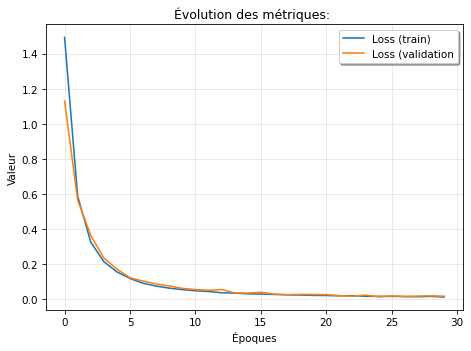

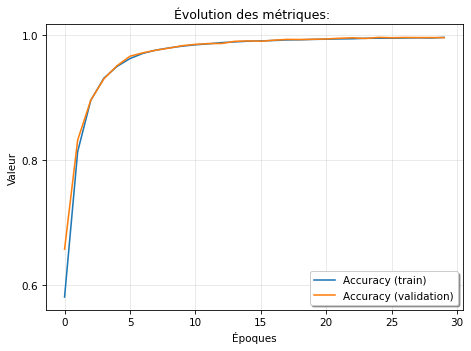

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(N_EPOCHS):
    train_loss, train_accuracy = train(epoch, model, loader, optimizer, criterion, CLIP)
    val_loss, val_accuracy = evaluate(model, loader, criterion)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

showPlot("", [train_losses, val_losses], ["Loss (train)", "Loss (validation"])
showPlot("", [train_accuracies, val_accuracies], ["Accuracy (train)", "Accuracy (validation)"])

## Sauvegarde / Chargement

In [ ]:
torch.save(model.state_dict(), "seq2seq.pt")

In [12]:
model.load_state_dict(torch.load("seq2seq.pt", map_location=device))
model.to(device)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(29, 32, padding_idx=0)
    (rnn): LSTM(32, 512, num_layers=4, batch_first=True, dropout=0.15, bidirectional=True)
    (dropout): Dropout(p=0.15, inplace=False)
    (hidden_projection): Linear(in_features=1024, out_features=512, bias=True)
    (cell_projection): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(32, 256, padding_idx=0)
    (rnn): LSTM(256, 512, num_layers=4, batch_first=True, dropout=0.25)
    (dropout): Dropout(p=0.25, inplace=False)
    (fc_out): Linear(in_features=512, out_features=32, bias=True)
  )
)

## Hyperparameter tuning

In [13]:
# Fonction utilitaire
def rand_log_uniform(low, high):
    """
    Tire une valeur aléatoire suivant une distribution log-uniforme
    entre 'low' et 'high'.
    
    Paramètres:
        low (float)  : borne inférieure (>0)
        high (float) : borne supérieure (>0)
    
    Retour:
        float : valeur tirée
    """
    if low <= 0 or high <= 0:
        raise ValueError("Les bornes doivent être strictement positives pour un tirage log-uniforme.")

    log_low = np.log(low)
    log_high = np.log(high)
    return float(np.exp(np.random.uniform(log_low, log_high)))

def mySort(k):
    return results[k][0][-1]

# Retourne une liste qui est la moyenne des listes de values
def computeFoldMeans(allValues:list[list[float]]):
    means = [0]*max([len(values) for values in allValues])
    for values in allValues:
        for i in range(len(values)):
            means[i] += values[i]
    for i in range(len(means)):
        means[i] = means[i]/len(allValues)
    return means

In [ ]:
# Encode les dataset src et trg en tensor numériques (<=> tableaux PyTorch)
dataset = TranslationDataset(SRC, TRG, SRC_VOCAB, TRG_VOCAB)

# 1. On définit la fonction d'entraînement compatible Ray Tune
def train_seq2seq(config, train_loader, val_loader):
    # Configuration du modèle à partir de la config courante
    enc = Encoder(INPUT_DIM, config["ENC_EMB_DIM"], config["HID_DIM"], config["N_LAYERS"], config["ENC_DROPOUT"], config["BIDIRECTIONAL"])
    dec = Decoder(OUTPUT_DIM, config["DEC_EMB_DIM"], config["HID_DIM"], config["N_LAYERS"], config["DEC_DROPOUT"])
    model = Seq2Seq(enc, dec, device).to(device)
    
    optimizer = optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["LR"])
    criterion = torch.nn.CrossEntropyLoss()
    
    CLIP = 1
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    for epoch in range(config["N_EPOCHS"]):
        train_loss, train_accuracy = train(epoch, model, train_loader, optimizer, criterion, CLIP)
        val_loss, val_accuracy = evaluate(model, val_loader, criterion)
        # si les metriques ne sont pas meilleures que les meilleures des 5 dernières époques, arrêter
        if ((len(train_losses) > 10 and train_loss > min(train_losses[-5:]))
            or (len(val_losses) > 10 and val_loss > min(val_losses[-5:]))
            or (len(train_accuracies) > 10 and train_accuracy < max(train_accuracies[-5:]))
            or (len(val_accuracies) > 10 and val_accuracy < max(val_accuracies[-5:]))):
            break
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
    return train_losses, val_losses, train_accuracies, val_accuracies
        

# 2. Définir l'espace de recherche des hyperparamètres
searchSpace = [
    {"Key":0, "BATCH_SIZE":16, "BIDIRECTIONAL":True, "DEC_DROPOUT": 0.440819, "DEC_EMB_DIM": 64, "ENC_DROPOUT": 0.31331, "ENC_EMB_DIM": 128, "HID_DIM": 256, "LR": 0.00023299, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":13, "BATCH_SIZE":32, "BIDIRECTIONAL":True, "DEC_DROPOUT": 0.161197, "DEC_EMB_DIM": 64, "ENC_DROPOUT": 0.269328, "ENC_EMB_DIM": 64, "HID_DIM": 128, "LR": 0.000818817, "N_LAYERS": 2, "N_EPOCHS": 40},
    #{'Key': 15, 'BATCH_SIZE': 64, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.4523098700525877, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.12384329060555066, 'ENC_EMB_DIM': 128, 'HID_DIM': 256, 'LR': 0.0027379544875619807, 'N_LAYERS': 3, 'N_EPOCHS': 40},
    #{'Key': 18, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.43325387434248197, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.42355256223853666, 'ENC_EMB_DIM': 128, 'HID_DIM': 256, 'LR': 0.00022905089776058659, 'N_LAYERS': 2, 'N_EPOCHS': 40},
    #{'Key': 19, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.32843793749563344, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.21262652633947465, 'ENC_EMB_DIM': 64, 'HID_DIM': 128, 'LR': 0.0011721132802202329, 'N_LAYERS': 2, 'N_EPOCHS': 40},
    #{'Key': 23, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.29433368582798347, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.43349293690802104, 'ENC_EMB_DIM': 256, 'HID_DIM': 128, 'LR': 0.0035036927184472575, 'N_LAYERS': 2, 'N_EPOCHS': 40},
    #{"Key":666, "BATCH_SIZE":64, "BIDIRECTIONAL":True, "DEC_DROPOUT": 0.440819, "DEC_EMB_DIM": 128, "ENC_DROPOUT": 0.31331, "ENC_EMB_DIM": 128, "HID_DIM": 512, "LR": 0.00023299, "N_LAYERS": 2, "N_EPOCHS": 40},
    #{'Key': 668, 'BATCH_SIZE': 16, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.2552553998721213, 'DEC_EMB_DIM': 64, 'ENC_DROPOUT': 0.3657303778805584, 'ENC_EMB_DIM': 256, 'HID_DIM': 128, 'LR': 0.0009012085107005741, 'N_LAYERS': 4, 'N_EPOCHS': 40},
    #{'Key': 670, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.224323490472932, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.16888275099579236, 'ENC_EMB_DIM': 128, 'HID_DIM': 512, 'LR': 0.0029438767377576295, 'N_LAYERS': 2, 'N_EPOCHS': 40},
    #{'Key': 671, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.31978820050973733, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.2877104784508834, 'ENC_EMB_DIM': 256, 'HID_DIM': 512, 'LR': 0.0001296001591769794, 'N_LAYERS': 2, 'N_EPOCHS': 40}
    #{"Key":1, "BATCH_SIZE":16, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.440819, "DEC_EMB_DIM": 64, "ENC_DROPOUT": 0.31331, "ENC_EMB_DIM": 128, "HID_DIM": 256, "LR": 0.00023299, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":2, "BATCH_SIZE":32, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.179608, "DEC_EMB_DIM": 32, "ENC_DROPOUT": 0.389179, "ENC_EMB_DIM": 128, "HID_DIM": 64, "LR": 0.00243355, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":6, "BATCH_SIZE":32, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.161197, "DEC_EMB_DIM": 64, "ENC_DROPOUT": 0.269328, "ENC_EMB_DIM": 64, "HID_DIM": 128, "LR": 0.000818817, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":7, "BATCH_SIZE":16, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.341104, "DEC_EMB_DIM": 64, "ENC_DROPOUT": 0.162988, "ENC_EMB_DIM": 64, "HID_DIM": 256, "LR": 0.00164443, "N_LAYERS": 4, "N_EPOCHS": 20},
    #{"Key":9, "BATCH_SIZE":64, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.120318, "DEC_EMB_DIM": 32, "ENC_DROPOUT": 0.370962, "ENC_EMB_DIM": 128, "HID_DIM": 128, "LR": 0.00427946, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":12, "BATCH_SIZE":32, "BIDIRECTIONAL":True, "DEC_DROPOUT": 0.179608, "DEC_EMB_DIM": 32, "ENC_DROPOUT": 0.389179, "ENC_EMB_DIM": 128, "HID_DIM": 64, "LR": 0.00243355, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":14, "BATCH_SIZE":16, "BIDIRECTIONAL":True, "DEC_DROPOUT": 0.341104, "DEC_EMB_DIM": 64, "ENC_DROPOUT": 0.162988, "ENC_EMB_DIM": 64, "HID_DIM": 256, "LR": 0.00164443, "N_LAYERS": 4, "N_EPOCHS": 20},
    #{"Key":15, "BATCH_SIZE":64, "BIDIRECTIONAL":True, "DEC_DROPOUT": 0.120318, "DEC_EMB_DIM": 32, "ENC_DROPOUT": 0.370962, "ENC_EMB_DIM": 128, "HID_DIM": 128, "LR": 0.00427946, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":3, "BATCH_SIZE":16, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.169886, "DEC_EMB_DIM": 128, "ENC_DROPOUT": 0.151859, "ENC_EMB_DIM": 64, "HID_DIM": 64, "LR": 0.00159483, "N_LAYERS": 3, "N_EPOCHS": 20},
    #{"Key":4, "BATCH_SIZE":64, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.248212, "DEC_EMB_DIM": 32, "ENC_DROPOUT": 0.392177, "ENC_EMB_DIM": 128, "HID_DIM": 128, "LR": 0.000198061, "N_LAYERS": 2, "N_EPOCHS": 20},
    #{"Key":5, "BATCH_SIZE":64, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.187711, "DEC_EMB_DIM": 64, "ENC_DROPOUT": 0.223163, "ENC_EMB_DIM": 32, "HID_DIM": 64, "LR": 0.000628239, "N_LAYERS": 4, "N_EPOCHS": 20},
    #{"Key":8, "BATCH_SIZE":32, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.109767, "DEC_EMB_DIM": 128, "ENC_DROPOUT": 0.433458, "ENC_EMB_DIM": 32, "HID_DIM": 128, "LR": 0.00603545, "N_LAYERS": 3, "N_EPOCHS": 20},
    #{"Key":10, "BATCH_SIZE":32, "BIDIRECTIONAL":False, "DEC_DROPOUT": 0.162927, "DEC_EMB_DIM": 128, "ENC_DROPOUT": 0.303756, "ENC_EMB_DIM": 32, "HID_DIM": 64, "LR": 0.000352071, "N_LAYERS": 2, "N_EPOCHS": 20}
]

# Compléter l'espace de recherche avec des valeurs aléatoires
keyMax = 0
for c in searchSpace:
    keyMax = c["Key"] if c["Key"] > keyMax else keyMax
for _ in range(150):
    keyMax += 1
    searchSpace.append({
        "Key":keyMax,
        "BATCH_SIZE":choice([16, 32, 64, 128, 256]),
        "BIDIRECTIONAL":choice([True, False]),
        "DEC_DROPOUT": choice([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]),
        "DEC_EMB_DIM": choice([16, 32, 64, 128, 256]),
        "ENC_DROPOUT": choice([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]),
        "ENC_EMB_DIM": choice([16, 32, 64, 128, 256]),
        "HID_DIM": choice([16, 32, 64, 128, 256, 512]),
        "LR": choice([0.0096, 0.0004, 0.0002, 0.0012, 0.0001, 0.0019, 0.0031, 0.0004, 0.0018, 0.0073, 0.0001, 0.0069, 0.002, 0.0041, 0.0012, 0.009, 0.0001, 0.0004, 0.0002, 0.0074, 0.0004, 0.0037, 0.0004, 0.0018, 0.0016, 0.0047, 0.0011, 0.0045, 0.0002, 0.0005, 0.0072, 0.001, 0.0067, 0.0015, 0.0004, 0.0004, 0.0001, 0.0026, 0.0007, 0.0001, 0.0011, 0.0025, 0.0082, 0.0049, 0.0003, 0.0039, 0.008, 0.0001, 0.0002, 0.0004]),
        "N_LAYERS": choice([2, 4, 8, 16]),
        "N_EPOCHS": 20
    })

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
splits = list(kf.split(dataset))

results = {}
# Parcourir toutes les configurations
for config in searchSpace:
    start = time.time()
    clear_output(wait=True)
    
    # Résultats par fold
    all_train_losses, all_val_losses, all_train_accs, all_val_accs = [], [], [], []

    # Rechercher parmis toutes les configurations testées les 5 meilleures
    bestConfigs = []
    for k in results:
        if len(bestConfigs) < 5:
            bestConfigs.append(k)
            bestConfigs.sort(key=mySort)
        else:
            # si le dernier mean_train_losses de key de la session courrante est meilleur (plus petit) que le moins bon (le dernier) des meilleures configs, le prendre en compte 
            if results[k][0][-1] < results[bestConfigs[-1]][0][-1]:
                bestConfigs = bestConfigs[:-1]
                bestConfigs.append(k)
                bestConfigs.sort(key=mySort)
    # Affichage des meilleures configurations
    if len(bestConfigs) > 0:
        print(str(len(bestConfigs))+ " meilleures configurations :")
        for k in bestConfigs:
            print(str(next(obj for obj in searchSpace if obj["Key"] == k)) + " | Loss (train): "+str(results[k][0][-1])+"; Loss (val): "+str(results[k][1][-1])+"; Accuracy (train): "+str(results[k][2][-1])+"; Accuracy (val): "+str(results[k][3][-1]))

    
    print ("Configuration", str(config["Key"])+"/"+str(len(searchSpace)-1), config)
    # traiter cette configuration en folds
    for fold, (train_idx, val_idx) in enumerate(splits):
        print("=== Fold "+str(fold+1)+"/"+str(N_SPLITS)+" ===                    ")
        # Création des sous-datasets
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)
        # Construction des loaders pour charger les données par paquets homogènes
        train_loader = DataLoader(train_subset, batch_size=config["BATCH_SIZE"], collate_fn=collate_fn, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=config["BATCH_SIZE"], collate_fn=collate_fn, shuffle=False)
        
        # Initialisation d'un nouveau modèle pour chaque fold
        train_losses, val_losses, train_accuracies, val_accuracies = train_seq2seq(config, train_loader, val_loader)
        results[config["Key"]] = (train_losses, val_losses, train_accuracies, val_accuracies)
            
        # Sauvegarder les résultats de ce fold
        all_train_losses.append(train_losses)
        all_val_losses.append(val_losses)
        all_train_accs.append(train_accuracies)
        all_val_accs.append(val_accuracies)

    mean_train_losses = computeFoldMeans(all_train_losses)
    mean_val_losses = computeFoldMeans(all_val_losses)
    mean_train_accs = computeFoldMeans(all_train_accs)
    mean_val_accs = computeFoldMeans(all_val_accs)

    results[config["Key"]] = (mean_train_losses, mean_val_losses, mean_train_accs, mean_val_accs)
    elapsed = time.time() - start
    print(f"Temps écoulé: {elapsed/60:.2f} minutes")        



5 meilleures configurations :
{'Key': 11, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.3, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.4, 'ENC_EMB_DIM': 256, 'HID_DIM': 32, 'LR': 0.0025, 'N_LAYERS': 4, 'N_EPOCHS': 20} | Loss (train): 0.5818353113929431; Loss (val): 1.1650333567261697; Accuracy (train): 0.3176816981002612; Accuracy (val): 0.2663337972676877
{'Key': 2, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.4, 'DEC_EMB_DIM': 32, 'ENC_DROPOUT': 0.5, 'ENC_EMB_DIM': 128, 'HID_DIM': 256, 'LR': 0.0072, 'N_LAYERS': 4, 'N_EPOCHS': 20} | Loss (train): 1.1300873980522155; Loss (val): 2.806790452818076; Accuracy (train): 0.4704278545046997; Accuracy (val): 0.28218142286456516
{'Key': 4, 'BATCH_SIZE': 256, 'BIDIRECTIONAL': False, 'DEC_DROPOUT': 0.45, 'DEC_EMB_DIM': 256, 'ENC_DROPOUT': 0.1, 'ENC_EMB_DIM': 128, 'HID_DIM': 512, 'LR': 0.009, 'N_LAYERS': 8, 'N_EPOCHS': 20} | Loss (train): 1.3910783402125042; Loss (val): 2.505409635995564; Accuracy (train): 0.3031466842686493; Ac

In [24]:
import pandas as pd
pd.DataFrame(searchSpace)

,Key,BATCH_SIZE,BIDIRECTIONAL,DEC_DROPOUT,DEC_EMB_DIM,ENC_DROPOUT,ENC_EMB_DIM,HID_DIM,LR,N_LAYERS,N_EPOCHS
0,0,16,True,0.440819,64,0.31331,128,256,0.000233,2,20
1,1,16,True,0.050000,128,0.30000,64,32,0.000400,8,20
2,2,256,True,0.150000,16,0.25000,64,64,0.007400,16,20
3,3,128,False,0.150000,64,0.45000,32,512,0.004100,2,20
4,4,64,True,0.050000,64,0.05000,256,256,0.000300,8,20
...,...,...,...,...,...,...,...,...,...,...,...
146,146,128,True,0.400000,16,0.10000,32,16,0.008000,8,20
147,147,64,False,0.300000,16,0.20000,128,64,0.001200,4,20
148,148,32,False,0.300000,16,0.05000,32,128,0.000200,4,20
149,149,64,False,0.100000,16,0.25000,64,32,0.007200,16,20


5 meilleures configurations :
{'Key': 0, 'BATCH_SIZE': 16, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.440819, 'DEC_EMB_DIM': 64, 'ENC_DROPOUT': 0.31331, 'ENC_EMB_DIM': 128, 'HID_DIM': 256, 'LR': 0.00023299, 'N_LAYERS': 2, 'N_EPOCHS': 20}
{'Key': 1, 'BATCH_SIZE': 32, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.1, 'DEC_EMB_DIM': 64, 'ENC_DROPOUT': 0.15, 'ENC_EMB_DIM': 16, 'HID_DIM': 256, 'LR': 0.0049, 'N_LAYERS': 16, 'N_EPOCHS': 20}
{'Key': 2, 'BATCH_SIZE': 128, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.3, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.05, 'ENC_EMB_DIM': 128, 'HID_DIM': 128, 'LR': 0.0041, 'N_LAYERS': 8, 'N_EPOCHS': 20}
{'Key': 3, 'BATCH_SIZE': 16, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.35, 'DEC_EMB_DIM': 128, 'ENC_DROPOUT': 0.3, 'ENC_EMB_DIM': 16, 'HID_DIM': 256, 'LR': 0.0015, 'N_LAYERS': 8, 'N_EPOCHS': 20}
{'Key': 4, 'BATCH_SIZE': 128, 'BIDIRECTIONAL': True, 'DEC_DROPOUT': 0.2, 'DEC_EMB_DIM': 256, 'ENC_DROPOUT': 0.4, 'ENC_EMB_DIM': 256, 'HID_DIM': 64, 'LR': 0.0003, 'N_LAYERS': 8, 'N_EPOC

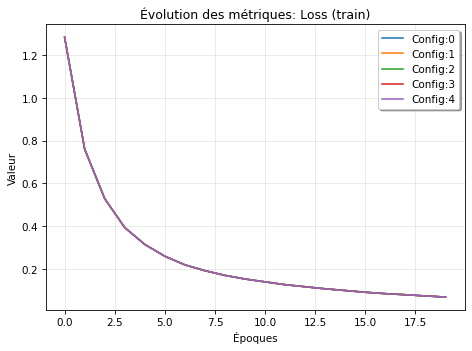

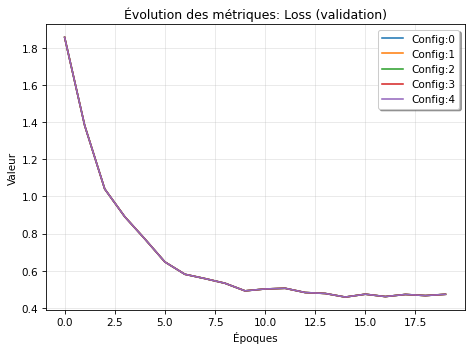

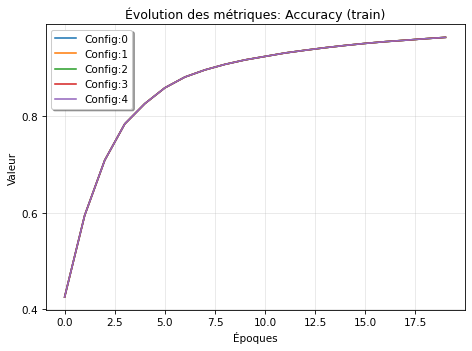

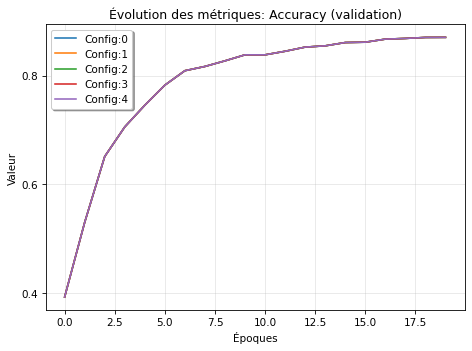

In [38]:
keys = []
trains_loss = []
trains_accuracies = []
vals_loss = []
vals_accuracies = []
print(str(len(bestConfigs))+ " meilleures configurations :")
for k in bestConfigs:
    keys.append("Config:"+str(k))
    trains_loss.append(results[k][0])
    vals_loss.append(results[k][1])
    trains_accuracies.append(results[k][2])
    vals_accuracies.append(results[k][3])
    print(next(obj for obj in searchSpace if obj["Key"] == k))

showPlot("Loss (train)", trains_loss, keys)
showPlot("Loss (validation)", vals_loss, keys)
showPlot("Accuracy (train)", trains_accuracies, keys)
showPlot("Accuracy (validation)", vals_accuracies, keys)

## Test de traduction

In [42]:

from torchviz import make_dot
from torchview import draw_graph
import hiddenlayer as hl

def evaluate_sentence(sentence, src_vocab, trg_vocab, model, max_len=20):
    model.eval()
    
    # Tokenisation de la phrase source
    tokens = sentence.split()
    src_indexes = [src_vocab[tok] for tok in tokens if tok in src_vocab]
    src_tensor = torch.tensor(src_indexes, dtype=torch.long).unsqueeze(0).to(device)
    
    # Encoder
    hidden, cell = model.encoder(src_tensor)# Pour visualiser le modèle construit
    #make_dot(hidden, params=dict(model.named_parameters()), show_attrs=False).render("seq2seq_model", format="png")
    #draw_graph(model, input_data=(src_tensor, src_tensor), expand_nested=False, graph_name='MyModel', save_graph=True, filename='model_architecture', directory='.')
    graph = hl.build_graph(model, (src_tensor, src_tensor))
    graph.theme = hl.themes.ColorBlind()
    graph.save("hiddenlayer_architecture.png")
    
    # Décodeur : on commence avec <sos>
    trg_indexes = [trg_vocab["<sos>"]]
    
    for i in range(max_len):
        trg_tensor = torch.tensor([trg_indexes[-1]], dtype=torch.long).to(device)
        with torch.no_grad():
            output, hidden, cell = model.decoder(trg_tensor, hidden, cell)
        
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)
        
        # Arrêt si <eos>
        if pred_token == trg_vocab["<eos>"]:
            break
    
    # Conversion index → tokens
    itos = {i:s for s,i in trg_vocab.items()}
    trg_tokens = [itos[i] for i in trg_indexes]
    
    return trg_tokens[1:]  # on enlève <sos>

In [43]:
def evaluateRandomly(src_vocab, trg_vocab, model, n=10):
    for i in range(n):
        pair = choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words = evaluate_sentence(pair[0], src_vocab, trg_vocab, model)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

In [44]:
evaluateRandomly(SRC_VOCAB, TRG_VOCAB, model, 1)

> I E M I E I E M
= [ [ I E ] M ]


AttributeError: module 'torch.onnx' has no attribute '_optimize_trace'

In [32]:
sentence = "D C C C C C C C Y F F F F Y F Y F"
translation = evaluate_sentence(sentence, SRC_VOCAB, TRG_VOCAB, model)
print(" ".join(translation))

D [ C ] [ Y [ F ] ] <eos>


Calcul des données de comparaison avec les autes modèles
=====================================================
On utilise la structure de fichier construite à partir du fichier `long-comp_fortesting.txt` voir le notebook `1-MAP_IA_BuildDataSet.ipynb`

In [20]:
import os

def process_and_evaluate():
    exemple_dir = 'example'
    solutions_dir = exemple_dir+'/solutions'

    #identifier le nombre de scénario
    maxNb = 0
    for example_filename in os.listdir(exemple_dir):
        if example_filename.endswith(".log"):
            scenarNum = int(example_filename.split('_')[0])
            if scenarNum > maxNb:
                maxNb = scenarNum
    correct_counts = [0]*maxNb

    # Iterate over each file in the 'exemple' directory
    for example_filename in os.listdir(exemple_dir):
        if example_filename.endswith(".log"):
            # Construct the full file paths
            example_filepath = os.path.join(exemple_dir, example_filename)
            solution_filepath = os.path.join(solutions_dir, example_filename)
    
            # Read the content of the example file
            with open(example_filepath, 'r') as exemple_file:
                example_content = exemple_file.read().strip()
    
            # Add spaces between each character in the example content
            spaced_example_content = ' '.join(example_content)
    
            # Evaluate the spaced example content
            try:
                evaluated_result = evaluate_sentence(spaced_example_content, SRC_VOCAB, TRG_VOCAB, model)
            except Exception as e:
                print(f"Error evaluating {example_filename}: {e}")
                continue
    
            # Read the content of the solution file
            with open(solution_filepath, 'r') as solution_file:
                solution_content = solution_file.read().strip()
    
            # Remove special characters from the evaluated result
            evaluated_result = [char for char in evaluated_result if char not in ['<eos>', '<sos>', '<pad>', 'sos', 'eos', 'pad']]
    
            # Convert the evaluated result to a string format
            evaluated_result_str = ''.join(evaluated_result)
    
            # Print intermediate results for debugging
            print(f"File: {example_filename}")
            print(f"Evaluated Result: {evaluated_result_str}")
            print(f"Solution Content: {solution_content}")
    
            # Compare the evaluated result with the solution content
            if evaluated_result_str == solution_content:
                case_number = int(example_filename.split('_')[0]) - 1
                correct_counts[case_number] += 1
            #    print("Match found!")
            #else:
            #    print("No match.")
    
            #print("-" * 40)  # Separator for clarity

    return correct_counts

# Process and evaluate the files
correct_counts = process_and_evaluate()
print(str(correct_counts)+ " => "+str(sum(correct_counts)))

File: 10_10_.log
Evaluated Result: G[N]SVBCJ[X]K
Solution Content: G[N]SVBCJ[X]K
File: 10_1_.log
Evaluated Result: I[Z]MP[W]B
Solution Content: I[Z]MP[W]B
File: 10_2_.log
Evaluated Result: I[S]XUNLNNC[W]V
Solution Content: I[S]XUZBLNC[W]V
File: 10_3_.log
Evaluated Result: I[H]NB[V]P
Solution Content: I[H]NB[V]P
File: 10_4_.log
Evaluated Result: W[Q]AXJ[G]N
Solution Content: W[Q]AXJ[G]N
File: 10_5_.log
Evaluated Result: O[D]AIGVZTTHJ[D]L
Solution Content: O[U]NIGAVZTHJ[D]L
File: 10_6_.log
Evaluated Result: C[L]QRXAFKMP[U]E
Solution Content: C[L]YAXRFKMP[U]E
File: 10_7_.log
Evaluated Result: K[D]JUMLVT[I]N
Solution Content: K[D]JUMLVT[I]N
File: 10_8_.log
Evaluated Result: V[Q]MEXTOE[N]I
Solution Content: V[Q]MEXTOG[N]I
File: 10_9_.log
Evaluated Result: V[X]FRDPT[O]C
Solution Content: V[X]RFDPT[O]C
File: 11_10_.log
Evaluated Result: P[A][M[F]]
Solution Content: P[A][M[F]]
File: 11_1_.log
Evaluated Result: I[A][J[M]]
Solution Content: I[A][J[M]]
File: 11_2_.log
Evaluated Result: H[P][O[K]]

In [19]:
#outputResult = 'exportResults_Seq2Seq_LSTM.txt'
outputResult = 'exportResults_alter_Seq2Seq_LSTM.txt'

file = open(outputResult, 'w')
file.write(str(correct_counts))
file.close()

## Mémoire de run précédents